In [40]:
from qiskit import *
from qiskit_aer import AerSimulator, StatevectorSimulator
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
import matplotlib.pyplot as plt

# Data generation

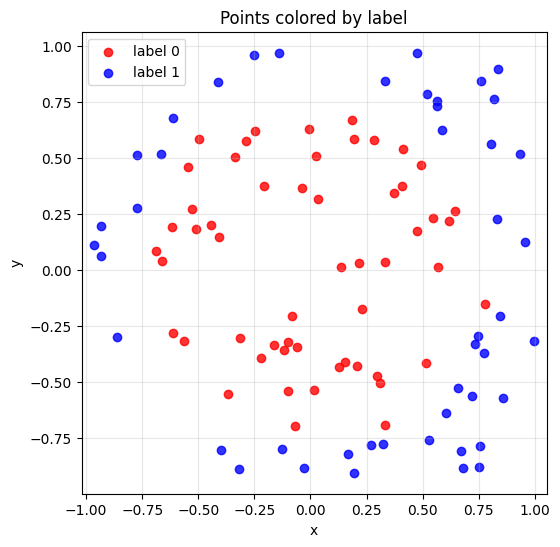

points in label 0: 54
points in label 1: 46


In [41]:
n = 100
points = np.random.rand(n, 2) * 2 - 1
labels = [0 if x**2 + y**2 < 2/np.pi else 1 for x, y in points]


import matplotlib.pyplot as plt

arr = np.array(points)
lbl = np.array(labels)

plt.figure(figsize=(6, 6))
plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Points colored by label")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("points in label 0:", np.sum(lbl == 0))
print("points in label 1:", np.sum(lbl == 1))

In [42]:

test_size = 0.2
rng = np.random.default_rng(42)

indices = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - test_size))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (80, 2) y_train: (80,)
X_test : (20, 2) y_test : (20,)


In [43]:
def U(q, theta, omega, x, qubit):
    wx = np.multiply(np.asarray(omega), np.asarray(x))  # Hadamard product
    q.rx(theta[0] + wx[0], qubit)
    q.rz(theta[1] + wx[1], qubit)

In [44]:
def U_su2(q, theta, omega, x, qubit):
    x3d = [x[0], x[1], 0] # Add a third dimension with value 0
    # phi_i = theta_i + w_i * x_i
    val_0 = theta[0] + omega[0] * x3d[0]
    val_1 = theta[1] + omega[1] * x3d[1]
    val_2 = theta[2] + omega[2] * x3d[2]
    
    q.u(val_0, val_1, val_2, qubit)

In [45]:
rc = 3

def create_circuit(x, theta, omega, measure=True):
    qc = QuantumCircuit(1)
    for i in range(rc):
        U_su2(qc, theta[i], omega[i], x, 0)
    if measure:
        qc.measure_all()
    return qc


In [46]:
theta = [[1,1,1] for _ in range(rc)]
omega = [[1,1,1] for _ in range(rc)]
qc =create_circuit(X_train[0], theta, omega)
qc.draw()

IndexError: list index out of range

In [27]:
sv_sim = StatevectorSimulator()

def get_prob_zero(circuit):
    """
    Retourne la probabilité d'état |0⟩ via simulation statevector (pas de shots).
    """
    qc_no_meas = create_circuit.__wrapped__(circuit) if hasattr(create_circuit, '__wrapped__') else circuit
    sv = sv_sim.run(transpile(qc_no_meas, sv_sim)).result().get_statevector()
    return float(abs(sv[0])**2)

def cost_function(theta, omega, X_train, y_train):
    """
    Calcule le coût en batch : un seul transpile + run pour tous les points.
    """
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]
    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()

    total_cost = 0.0
    for i, y in enumerate(y_train):
        sv = results.get_statevector(i)
        prob_0 = float(abs(sv[0])**2)
        predicted_prob = prob_0 if y == 0 else (1 - prob_0)
        total_cost += (1 - predicted_prob)
    return total_cost / len(y_train)


In [28]:
import numpy as np
from scipy.optimize import minimize



def unpack_params(params, rc):
    split = 3 * rc
    theta = params[:split].reshape(rc, 3)
    omega = params[split:].reshape(rc, 3)
    return theta, omega

def objective(params, X_train, y_train, rc):
    theta, omega = unpack_params(params, rc)
    return cost_function(theta, omega, X_train, y_train)



def optimize_parameters(X_train, y_train, rc, maxiter=80, seed=42):
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=6 * rc)

    step = {"k": 0}
    def cb(xk):
        step["k"] += 1
        print(f"Step {step['k']:03d}")

    res = minimize(
        objective,
        init,
        args=(X_train, y_train, rc),
        method="COBYLA",
        callback=cb,
        options={"maxiter": maxiter}
    )

    theta_opt, omega_opt = unpack_params(res.x, rc)
    print(f"Final cost = {res.fun:.6f}")
    return theta_opt, omega_opt, res

In [29]:
def predict_batch(X, theta, omega):
    """
    Prédit les labels pour tous les points X en un seul appel sim.run.
    """
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()
    preds = []
    for i in range(len(X)):
        sv = results.get_statevector(i)
        prob_0 = float(abs(sv[0])**2)
        preds.append(0 if prob_0 >= 0.5 else 1)
    return np.array(preds)

def evaluate_precision(X, y, theta, omega, positive_label=1):
    y_pred = predict_batch(X, theta, omega)
    tp = np.sum((y_pred == positive_label) & (y == positive_label))
    fp = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    return precision

# --- train + test ---
theta_opt, omega_opt, res = optimize_parameters(X_train, y_train, rc, maxiter=80)
precision_test = evaluate_precision(X_test, y_test, theta_opt, omega_opt)

print("Final train cost:", res.fun)
print("Test precision:", precision_test)


Step 001
Step 002
Step 003
Step 004
Step 005
Step 006
Step 007
Step 008
Step 009


capi_return is NULL
Call-back cb_calcfc_in__cobyla__user__routines failed.


KeyboardInterrupt: 